# PANDORA Evaluation Analysis

This notebook analyzes **end-to-end** Big5Loop evaluation runs (`run_pandora_eval.py` → `/api/chat`): each line has `detected_ocean` (or `predicted_ocean`) and `ground_truth_ocean`.

**Preferred input location:** `evaluation_data/pandora/processed/pandora_eval_results_*.jsonl`.

Set `RESULTS_FILENAME` and `EXPECTED_SAMPLE_COUNT` in the first code cell. Typical Phase 5 run: **`python scripts/run_pandora_eval.py --limit 500 --output pandora/processed/pandora_eval_results_<name>.jsonl`** → **500 lines** in the JSONL; the load cell prints **line count** vs **valid rows** (both GT and prediction present).

For **offline multi-model** NVIDIA runs (`offline_detection_*.jsonl`), use `offline_nv_detection/OFFLINE-Detection-Analysis.ipynb` instead (or set that notebook’s `RESULTS_MODE = "api_chat"` to reuse the same JSONL).

## Output
- Correlation and MAE tables
- Scatter plots (detected vs ground truth)
- OCEAN heatmap
- Distribution by trait

In [16]:
from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

OCEAN_ORDER = ["O", "C", "E", "A", "N"]
OCEAN_LABELS = {
    "O": "Openness",
    "C": "Conscientiousness",
    "E": "Extraversion",
    "A": "Agreeableness",
    "N": "Neuroticism",
}

def find_project_root() -> Path:
    cwd = Path.cwd().resolve()
    for candidate in [cwd, *cwd.parents]:
        if (candidate / "evaluation_data").exists() and (candidate / "apps").exists():
            return candidate
        if (candidate / "big5loop" / "evaluation_data").exists() and (candidate / "big5loop" / "apps").exists():
            return candidate / "big5loop"
    raise RuntimeError("Could not locate Big5Loop project root from the current working directory.")

PROJECT_ROOT = find_project_root()
PANDORA_PROCESSED = PROJECT_ROOT / "evaluation_data" / "pandora" / "processed"

# Change this to any file produced by scripts/run_pandora_eval.py --output ...
RESULTS_FILENAME = "pandora_eval_results_v4_20260327-1.jsonl"
# Should match --limit N when you ran the eval (sanity check in the next cell).
EXPECTED_SAMPLE_COUNT = 500

RESULTS_PATH = PANDORA_PROCESSED / RESULTS_FILENAME
RESULTS_STEM = RESULTS_PATH.stem  # used when saving metrics

print("Project root:", PROJECT_ROOT)
print("Results path:", RESULTS_PATH)
print("Exists:", RESULTS_PATH.exists())
if RESULTS_PATH.exists():
    n_lines = sum(1 for _ in open(RESULTS_PATH, encoding="utf-8"))
    print("JSONL lines in file:", n_lines)
    if EXPECTED_SAMPLE_COUNT is not None and n_lines != EXPECTED_SAMPLE_COUNT:
        print(f"Note: line count ({n_lines}) != EXPECTED_SAMPLE_COUNT ({EXPECTED_SAMPLE_COUNT})")

Project root: /Users/huaduojiejia/MyProject/hslu/2026/thesis project/big5loop
Results path: /Users/huaduojiejia/MyProject/hslu/2026/thesis project/big5loop/evaluation_data/pandora/processed/pandora_eval_results_v4_20260327-1.jsonl
Exists: True


In [ ]:
rows_raw = []
with open(RESULTS_PATH, "r", encoding="utf-8") as f:
    for line in f:
        line = line.strip()
        if not line:
            continue
        rows_raw.append(json.loads(line))

jsonl_lines = len(rows_raw)
skipped = []
rows = []
for r in rows_raw:
    gt = r.get("ground_truth_ocean")
    pred = r.get("detected_ocean") or r.get("predicted_ocean")
    if gt and pred:
        rows.append(r)
    else:
        skipped.append(r.get("sample_id"))

records = []
for r in rows:
    pred = r.get("detected_ocean") or r.get("predicted_ocean")
    rec = {"sample_id": r.get("sample_id")}
    for t in OCEAN_ORDER:
        rec[f"gt_{t}"] = float((r["ground_truth_ocean"] or {}).get(t, 0.0))
        rec[f"pred_{t}"] = float((pred or {}).get(t, 0.0))
    records.append(rec)

df = pd.DataFrame(records)
print("JSONL rows:", jsonl_lines)
print("Valid rows (GT + prediction):", len(df))
if skipped:
    print("Skipped (missing GT or prediction):", len(skipped), "sample_id(s):", skipped[:10], "..." if len(skipped) > 10 else "")
if EXPECTED_SAMPLE_COUNT is not None:
    if len(df) != EXPECTED_SAMPLE_COUNT:
        print(f"Warning: valid rows ({len(df)}) != EXPECTED_SAMPLE_COUNT ({EXPECTED_SAMPLE_COUNT})")
df.head(3)

Valid rows: 499


,sample_id,gt_O,pred_O,gt_C,pred_C,gt_E,pred_E,gt_A,pred_A,gt_N,pred_N
0,2818053,-0.88,0.366667,-0.1,0.533333,-0.64,0.266667,0.78,0.600000,0.86,-0.166667
1,1936136,0.10,0.633333,0.0,0.233333,-0.54,0.233333,-0.48,0.100000,0.74,-0.100000
2,2550699,-0.84,0.066667,-0.2,-0.300000,-0.22,0.600000,0.94,-0.166667,0.46,0.366667


In [ ]:
def spearman(a: pd.Series, b: pd.Series) -> float:
    return a.rank().corr(b.rank(), method="pearson")

summary = []
for t in OCEAN_ORDER:
    gt = df[f"gt_{t}"]
    pred = df[f"pred_{t}"]
    pearson = float(gt.corr(pred, method="pearson")) if gt.std() > 0 and pred.std() > 0 else 0.0
    spear = float(spearman(gt, pred)) if gt.std() > 0 and pred.std() > 0 else 0.0
    mae = float((pred - gt).abs().mean())
    sign_agree = float((((np.sign(pred) == np.sign(gt)).sum()) / len(df))) if len(df) else 0.0
    summary.append({"trait": t, "pearson": pearson, "spearman": spear, "mae": mae, "sign_agreement": sign_agree})

metrics_df = pd.DataFrame(summary)
metrics_df

,trait,pearson,spearman,mae,sign_agreement
0,O,-0.056575,-0.039235,0.657088,0.390782
1,C,0.046130,0.036047,0.507943,0.460922
2,E,0.095841,0.105796,0.644796,0.326653
3,A,0.113805,0.136072,0.598233,0.420842
4,N,0.089553,0.081729,0.524041,0.464930


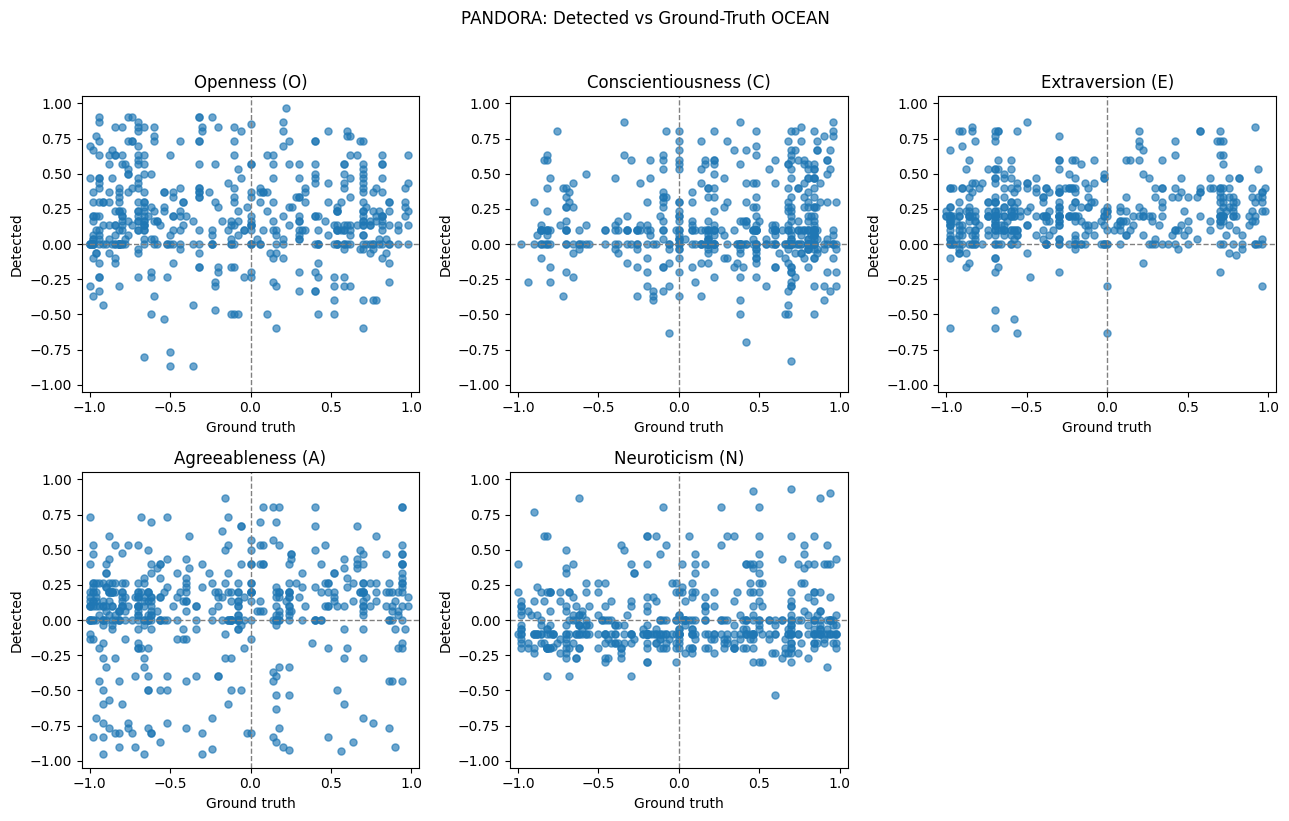

In [ ]:
# Scatter: detected vs ground truth per trait
fig, axes = plt.subplots(2, 3, figsize=(13, 8))
axes = axes.flatten()

for i, t in enumerate(OCEAN_ORDER):
    ax = axes[i]
    x = df[f"gt_{t}"]
    y = df[f"pred_{t}"]
    ax.scatter(x, y, alpha=0.65, s=26)
    ax.axhline(0, color="gray", linestyle="--", linewidth=1)
    ax.axvline(0, color="gray", linestyle="--", linewidth=1)
    ax.set_xlim(-1.05, 1.05)
    ax.set_ylim(-1.05, 1.05)
    ax.set_title(f"{OCEAN_LABELS[t]} ({t})")
    ax.set_xlabel("Ground truth")
    ax.set_ylabel("Detected")

axes[-1].axis("off")
plt.suptitle("PANDORA: Detected vs Ground-Truth OCEAN", y=1.02)
plt.tight_layout()
plt.show()

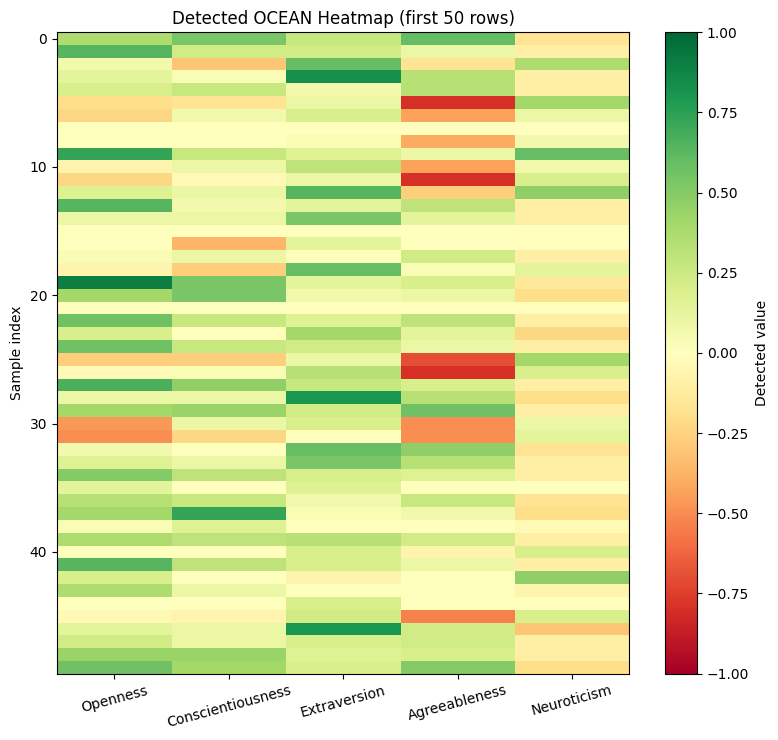

In [ ]:
# Heatmap: first N rows of detected OCEAN (cap for readability on large runs, e.g. 500 samples)
n_show = min(50, len(df))
mat = df[[f"pred_{t}" for t in OCEAN_ORDER]].head(n_show).values

plt.figure(figsize=(8, max(4, n_show * 0.15)))
plt.imshow(mat, aspect="auto", cmap="RdYlGn", vmin=-1, vmax=1)
plt.colorbar(label="Detected value")
plt.xticks(range(len(OCEAN_ORDER)), [OCEAN_LABELS[t] for t in OCEAN_ORDER], rotation=15)
plt.ylabel("Sample index")
plt.title(f"Detected OCEAN Heatmap (first {n_show} rows)")
plt.tight_layout()
plt.show()

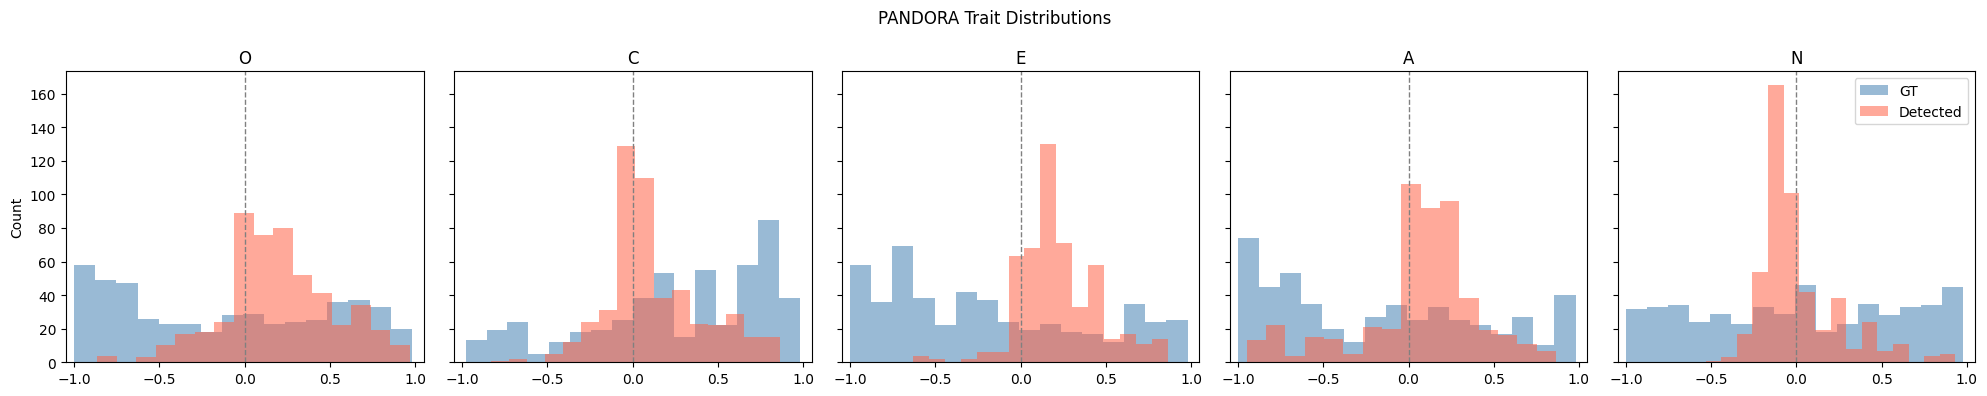

In [ ]:
# Distribution by trait: ground truth vs detected
fig, axes = plt.subplots(1, 5, figsize=(20, 4), sharey=True)
for i, t in enumerate(OCEAN_ORDER):
    ax = axes[i]
    ax.hist(df[f"gt_{t}"], bins=16, alpha=0.55, label="GT", color="steelblue")
    ax.hist(df[f"pred_{t}"], bins=16, alpha=0.55, label="Detected", color="tomato")
    ax.axvline(0, color="gray", linestyle="--", linewidth=1)
    ax.set_title(t)
    ax.set_xlim(-1.05, 1.05)

axes[0].set_ylabel("Count")
axes[-1].legend(loc="upper right")
plt.suptitle("PANDORA Trait Distributions")
plt.tight_layout()
plt.show()

In [ ]:
# Optional: save metrics to processed folder (names follow results file stem)
metrics_json = PANDORA_PROCESSED / f"pandora_eval_metrics_{RESULTS_STEM}_notebook.json"
metrics_csv = PANDORA_PROCESSED / f"pandora_eval_metrics_{RESULTS_STEM}_notebook.csv"

payload = {
    "n": int(len(df)),
    "traits": {
        row["trait"]: {
            "pearson": float(row["pearson"]),
            "spearman": float(row["spearman"]),
            "mae": float(row["mae"]),
            "sign_agreement": float(row["sign_agreement"]),
        }
        for _, row in metrics_df.iterrows()
    },
    "macro_avg": {
        "pearson": float(metrics_df["pearson"].mean()),
        "spearman": float(metrics_df["spearman"].mean()),
        "mae": float(metrics_df["mae"].mean()),
        "sign_agreement": float(metrics_df["sign_agreement"].mean()),
    },
}

with open(metrics_json, "w", encoding="utf-8") as f:
    json.dump(payload, f, ensure_ascii=False, indent=2)
metrics_df.to_csv(metrics_csv, index=False)

print("Saved:", metrics_json)
print("Saved:", metrics_csv)
payload["macro_avg"]

Saved: /Users/huaduojiejia/MyProject/hslu/2026/thesis project/big5loop/evaluation_data/pandora/processed/pandora_eval_metrics_sample100_from_notebook.json
Saved: /Users/huaduojiejia/MyProject/hslu/2026/thesis project/big5loop/evaluation_data/pandora/processed/pandora_eval_metrics_sample100_from_notebook.csv


{'pearson': 0.05775070139337994,
 'spearman': 0.06408169344132042,
 'mae': 0.5864201736806947,
 'sign_agreement': 0.41282565130260523}